<a href="https://colab.research.google.com/github/LorenzoBioinfo/import-bioinformatics/blob/main/notebooks/MultiSequenceAlignement_Phylogenetics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter:** 01 — Bioinformatics Foundations  
**Level:** Beginner → Intermediate  
**Estimated time:** ~2.5 hours  


## Cosa imparerai

- Scaricare un file multi-sequenza con Biopython

- Correre l'algoritmo MAFFT per Multi Sequence Alignment (MSA)

- Visualizzare l'allineamento con un *conservation plot* e *identity heatmap*

- Calcolare una matrice di distanza dall'allineamento

- Costruire e visualizzare un albero filogenetico con **UPGMA**  e **Neighbor-Joining**



### Allineamento Multiplo di Sequenze (MSA)

Quando si confrontano più sequenze contemporaneamente, è necessario allinearle in modo che le posizioni omologhe corrispondano correttamente.  
Un **Multiple Sequence Alignment (MSA)** inserisce gap (`-`) nei punti in cui una sequenza presenta inserzioni o delezioni rispetto alle altre, producendo una matrice rettangolare di caratteri allineati.

### Filogenetica in breve

Un **albero filogenetico** rappresenta le relazioni evolutive tra diverse sequenze biologiche.  
Due metodi classici basati sulle distanze sono:

| Metodo | Idea | Assunzione |
|--------|------|------------|
| **UPGMA** | Unisce iterativamente i due cluster più simili | Tasso evolutivo costante (orologio molecolare) |
| **Neighbor-Joining** | Corregge differenze nei tassi evolutivi prima dell’unione | I tassi evolutivi possono variare tra linee evolutive |

Per l’evoluzione reale dei virus, il metodo **Neighbor-Joining** è generalmente più accurato.  
**UPGMA** è più semplice e rappresenta un buon strumento didattico. Confrontare i due alberi permette di osservare dove l’assunzione dell’orologio molecolare non è valida.

### Dataset

Utilizziamo le sequenze nucleotidiche della **proteina spike** di 8 varianti di SARS-CoV-2, scaricate direttamente da NCBI.  
La proteina spike è una scelta ideale perché rappresenta il principale bersaglio di vaccini e anticorpi, ed è una delle regioni in cui le varianti accumulano più mutazioni.

0 Setup

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install biopython  --quiet
    !apt-get install -y mafft -qq

In [8]:
# Controlliamo che sia MAFFT sia installato
!mafft --help

------------------------------------------------------------------------------
  MAFFT v7.490 (2021/Oct/30)
  https://mafft.cbrc.jp/alignment/software/
  MBE 30:772-780 (2013), NAR 30:3059-3066 (2002)
------------------------------------------------------------------------------
High speed:
  % mafft in > out
  % mafft --retree 1 in > out (fast)

High accuracy (for <~200 sequences x <~2,000 aa/nt):
  % mafft --maxiterate 1000 --localpair  in > out (% linsi in > out is also ok)
  % mafft --maxiterate 1000 --genafpair  in > out (% einsi in > out)
  % mafft --maxiterate 1000 --globalpair in > out (% ginsi in > out)

If unsure which option to use:
  % mafft --auto in > out

--op # :         Gap opening penalty, default: 1.53
--ep # :         Offset (works like gap extension penalty), default: 0.0
--maxiterate # : Maximum number of iterative refinement, default: 0
--clustalout :   Output: clustal format, default: fasta
--reorder :      Outorder: aligned, default: input order
--quiet :      

In [2]:
from Bio import SeqIO, Entrez, AlignIO, Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
from io import StringIO
import subprocess
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

Entrez.email = 'your@email.com'


## 1 Download delle sequenze della Spike protein

Scarichiamo la proteina Spike (S gene) per 8 varianti del Sars-CoV-2.

Usiamo l'accession ID di NCBI.

In [3]:
VARIANTS = {
    'Wuhan-Hu-1'     : 'QHD43416.1',   # Strand originale di Wuhan
    'Alpha-B.1.1.7'  : 'QWK65230.1',
    'Beta-B.1.351'   : 'QRN78347.1',
    'Gamma-P.1'      : 'QTK07793.1',
    'Delta-B.1.617.2': 'UFO69279.1',
    'Omicron-BA.1'   : 'UJN89279.1',
    'Omicron-BA.2'   : 'UKH18985.1',
    'Omicron-XBB'    : 'UPP03721.1',
}

In [4]:
RAW_FASTA  = Path('spike_raw.fasta')
ALIGN_FILE = Path('spike_aligned.fasta')


if not RAW_FASTA.exists():
    print('Downloading spike protein sequences from NCBI...')
    records = []
    for name, acc in VARIANTS.items():
        handle = Entrez.efetch(db='protein', id=acc, rettype='fasta', retmode='text')
        rec = SeqIO.read(handle, 'fasta')

        rec.id = name
        rec.description = acc
        records.append(rec)
    SeqIO.write(records, RAW_FASTA, 'fasta')
    print(f'Saved {len(records)} sequences to {RAW_FASTA}')
else:
    records = list(SeqIO.parse(RAW_FASTA, 'fasta'))
    print(f'Loaded {len(records)} sequences from {RAW_FASTA}')


for r in records:
    print(f'  {r.id:<22} {len(r.seq):>5} aa')

Loaded 8 sequences from spike_raw.fasta
  Wuhan-Hu-1              1273 aa
  Alpha-B.1.1.7           1271 aa
  Beta-B.1.351            1270 aa
  Gamma-P.1                148 aa
  Delta-B.1.617.2         1270 aa
  Omicron-BA.1              38 aa
  Omicron-BA.2             542 aa
  Omicron-XBB             7092 aa


Bene! Abbiamo ora un file FASTA con le 8 sequenze delle varianti della proteina Spike.

Passiamo all'allineamento multiplo per

## 2 · Multiple Sequence Analysis


Leggiamo il file FASTA e estraiamo la lunghezza di ogni sequenza.
Stiamo lavorando con sequenze proteiche quindi non possiamo calcolare contenuto di GC o nucleotidico


In [5]:
# Leggiamo il file FASTA con SeqIO.parse()
records = list(SeqIO.parse("spike_raw.fasta", "fasta"))

rows = []
for r in records:
    seq = r.seq
    length = len(seq)
    rows.append({
        "Variant"  : r.id,
        "Length (aa)" : length,
        })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

        Variant  Length (aa)
     Wuhan-Hu-1         1273
  Alpha-B.1.1.7         1271
   Beta-B.1.351         1270
      Gamma-P.1          148
Delta-B.1.617.2         1270
   Omicron-BA.1           38
   Omicron-BA.2          542
    Omicron-XBB         7092


## 3 · Multiple Sequence Alignment con MAFFT

Passiamo ora all'allineamento multiplo. MAFFT è uno dei tool migliori in termini di velocità e accuratezza.
Biopython fino alla versione 1.79 aveva la funzione  *MuscleCommandline* per l'allineamento multiplo con MUSCLE ma è stata nelle versioni più recenti. Per questo motivo useremo MAFFT tramite subprocess


In [14]:
import shutil
mafft_path = shutil.which("mafft")
print(f"MAFFT path: {mafft_path}")


def run_mafft(input_fasta,output_fasta):

  result=subprocess.run(
      [mafft_path,'--auto','--quiet',str(input_fasta)],
      capture_output=True,
      text=True
  )

  if result.returncode==0:
    with open(output_fasta,'w') as f:
      f.write(result.stdout)
  else:
    print(result.stderr)



if not ALIGN_FILE.exists():
    print('Running MAFFT alignment...')
    success = run_mafft(RAW_FASTA, ALIGN_FILE)
    if success:
        print(f'Alignment saved to {ALIGN_FILE}')

else:
     print(f'Alignment already exists at {ALIGN_FILE}')






MAFFT path: /usr/bin/mafft
Running MAFFT alignment...


Passiamo ora a leggere il file FASTA dell'allineamento.

In [15]:
alignment = AlignIO.read(ALIGN_FILE, 'fasta')

In [16]:
print(f'Alignment shape: {len(alignment)} sequences × {alignment.get_alignment_length()} positions')

Alignment shape: 8 sequences × 7131 positions


Stampiamo le prime 80 posizioni dell'allineamento.

In [25]:
for record in alignment:
  print(f'{record.id:<22} {str(record.seq[:80])}')
print('-'*104)

Wuhan-Hu-1             M------------------------------------------------------------------FVFL---------
Alpha-B.1.1.7          M------------------------------------------------------------------FVFL---------
Beta-B.1.351           M------------------------------------------------------------------FVFL---------
Gamma-P.1              MTR----------------------VIIDG--------------------------------------------DA----
Delta-B.1.617.2        M------------------------------------------------------------------FVFL---------
Omicron-BA.1           M----------------------------G--------------------------------------------------
Omicron-BA.2           MNS-------------------NRSLLVMG--------------------------------------------------
Omicron-XBB            MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHLKDGTCGLVEVEKGVLPQLEQPYVFIKRSDARTAP
--------------------------------------------------------------------------------------------------------


## 4  Visualizziamo l'allienamento
### 4a · Conservation plot
Per ogni misura dell'allinemento, vediamo quanto è conservato un determinato aminoacido.
La posizione è *completamento conservata* se tutte le sequenze hanno lo stesso aminoacido.


Definiamo una funzione che ci fornisce uno *score di conservazione* (range 0-1) per ongi posizione dell'allineamento.




In [26]:
def conservation_per_position(alignment):

    n_seq = len(alignment)
    n_pos = alignment.get_alignment_length()
    scores = np.zeros(n_pos)

    for i in range(n_pos):
        col = alignment[:, i]         # Tutti i residui alla posizione i
        col_no_gap = col.replace('-', '')
        if not col_no_gap:
            scores[i] = 0
            continue
        most_common = max(set(col_no_gap), key=col_no_gap.count)
        scores[i] = col_no_gap.count(most_common) / len(col_no_gap)

    return scores

In [27]:
conservation = conservation_per_position(alignment)
positions = np.arange(len(conservation))

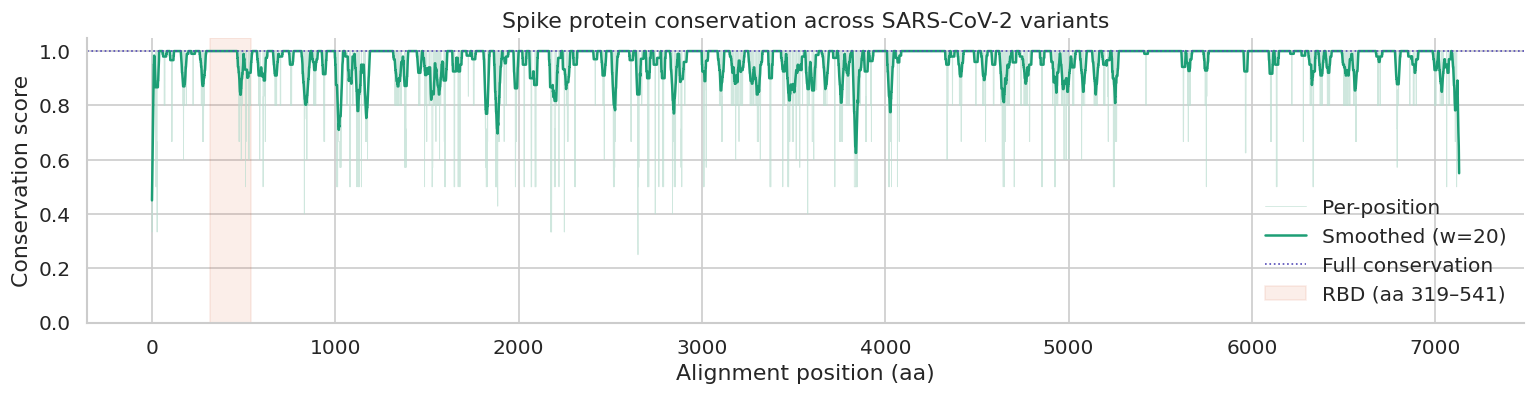

Fully conserved positions: 6146 / 7131 (86.2%)


In [30]:
window = 20
smoothed = np.convolve(conservation, np.ones(window)/window, mode='same')

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(positions, conservation, color='#BBDDD0', linewidth=0.5, alpha=0.7, label='Per-position')
ax.plot(positions, smoothed, color='#1D9E75', linewidth=1.5, label=f'Smoothed (w={window})')
ax.axhline(1.0, color='#534AB7', linestyle=':', linewidth=1, label='Full conservation')

# Evidenziamo la regione receptor-binding domain (RBD): ~positions 319–541
ax.axvspan(319, 541, alpha=0.1, color='#D85A30', label='RBD (aa 319–541)')

ax.set_xlabel('Alignment position (aa)')
ax.set_ylabel('Conservation score')
ax.set_title('Spike protein conservation across SARS-CoV-2 variants')
ax.legend(frameon=False, loc='lower right')
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.savefig('spike_conservation.png', dpi=150, bbox_inches='tight')
plt.show()

n_fully_conserved = (conservation == 1.0).sum()
print(f'Fully conserved positions: {n_fully_conserved} / {len(conservation)} '
      f'({n_fully_conserved/len(conservation)*100:.1f}%)')

### 4b Pairwise identity heatmap

Calcoliamo la percentuale di identità per ogni coppia di sequenze allineate (escludendo i gap)

In [33]:
def pairwise_identity_matrix(alignment):
  n=len(alignment)
  names=[r.id for r in alignment]
  matrix=np.zeros((n,n))


  for i in range(n):
    for j in range(n):
      seq_i=str(alignment[i].seq)
      seq_j=str(alignment[j].seq)
      matches=sum(a==b for a,b in zip(seq_i,seq_j) if a !='-' and b !='-')
      comparable=sum(1 for a,b in  zip(seq_i, seq_j)
                             if a != '-' and b != '-')
      matrix[i,j]=matches/comparable *100 if comparable else 0

  return pd.DataFrame(matrix, index=names,columns=names)


identity_df = pairwise_identity_matrix(alignment)

print(identity_df)


                 Wuhan-Hu-1  Alpha-B.1.1.7  Beta-B.1.351   Gamma-P.1  \
Wuhan-Hu-1       100.000000      99.370574     99.448819   33.043478   
Alpha-B.1.1.7     99.370574     100.000000     98.974763   32.173913   
Beta-B.1.351      99.448819      98.974763    100.000000   33.043478   
Gamma-P.1         33.043478      32.173913     33.043478  100.000000   
Delta-B.1.617.2   97.632202      97.549407     97.626582   33.913043   
Omicron-BA.1      33.333333      33.333333     33.333333   29.411765   
Omicron-BA.2      31.595092      31.595092     31.578947   23.404255   
Omicron-XBB       36.532258      36.510501     36.459175   37.414966   

                 Delta-B.1.617.2  Omicron-BA.1  Omicron-BA.2  Omicron-XBB  
Wuhan-Hu-1             97.632202     33.333333     31.595092    36.532258  
Alpha-B.1.1.7          97.549407     33.333333     31.595092    36.510501  
Beta-B.1.351           97.626582     33.333333     31.578947    36.459175  
Gamma-P.1              33.913043     29.411765 

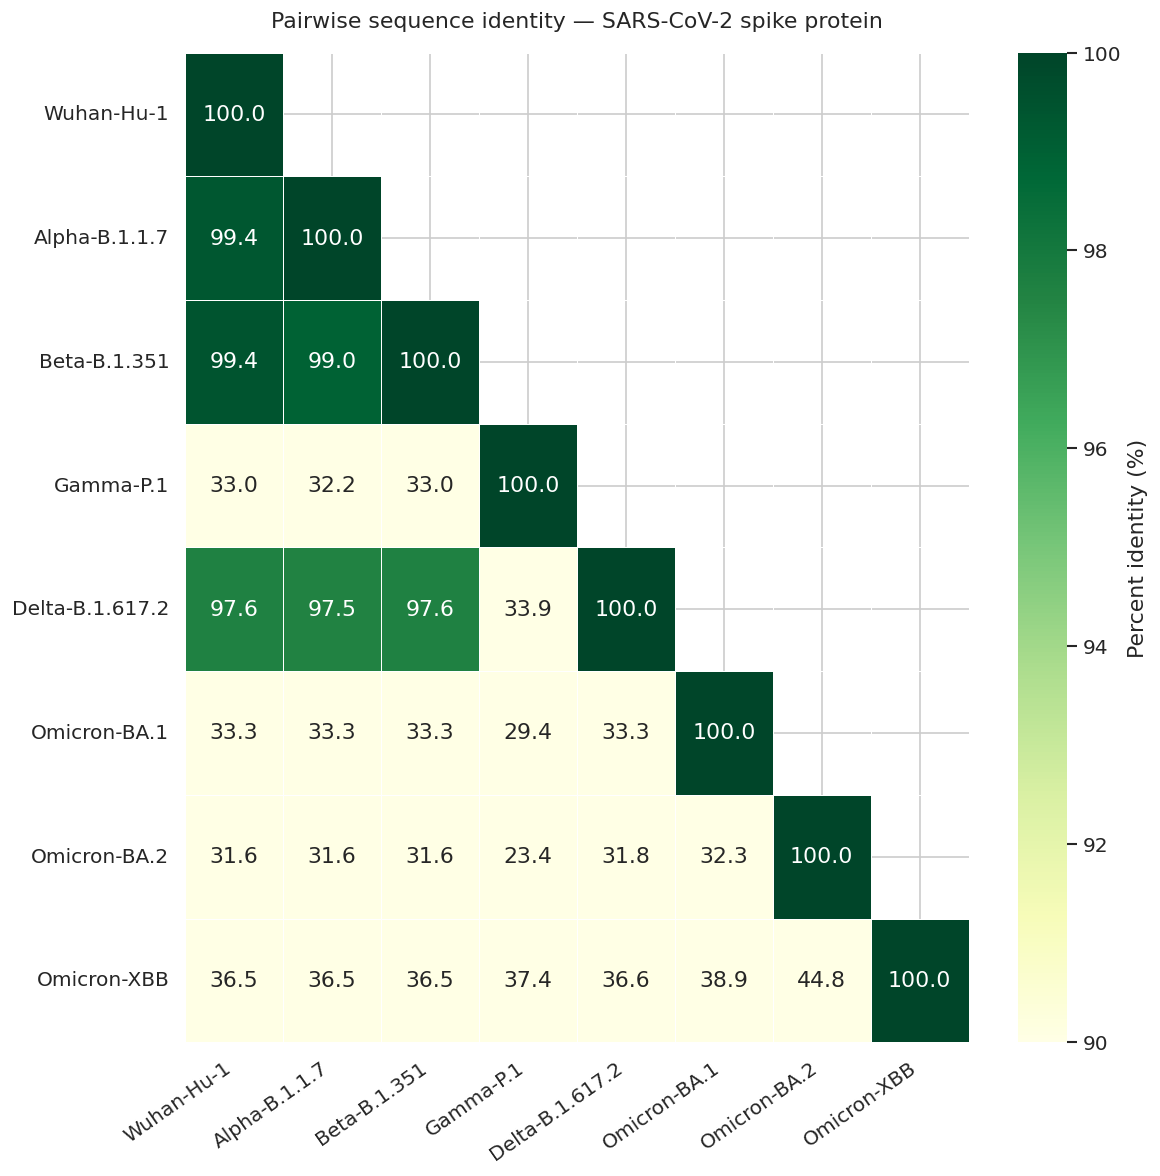

In [35]:
fig,ax =plt.subplots(figsize=(10,10))
mask = np.zeros_like(identity_df, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    identity_df,
    mask=mask,
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    vmin=90,
    vmax=100,
    linewidths=0.5,
    cbar_kws={'label': 'Percent identity (%)'},
    ax=ax
)
ax.set_title('Pairwise sequence identity — SARS-CoV-2 spike protein', pad=15)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('spike_identity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Matrice di Distanza

Per costruire un albero filogenetico è necessario convertire l’allineamento multiplo in una **matrice di distanza**, che quantifica quanto le sequenze differiscono tra loro.  

Biopython fornisce la classe `DistanceCalculator`, che permette di calcolare tali distanze utilizzando diversi modelli di sostituzione. In questo esempio utilizzeremo la matrice `'blosum62'`.

La **BLOSUM62** (*BLOcks SUbstitution Matrix*) è una matrice di sostituzione ampiamente usata per il confronto tra sequenze proteiche.  
Essa assegna un punteggio alle sostituzioni tra amminoacidi sulla base della frequenza con cui tali cambiamenti sono osservati in proteine evolutivamente correlate.

- valori **positivi** → sostituzioni frequenti e conservative;
- valori **negativi** → sostituzioni rare o biologicamente meno probabili.

BLOSUM62 rappresenta un buon compromesso tra sensibilità e accuratezza ed è per questo uno degli standard più utilizzati negli algoritmi di allineamento e analisi filogenetica.

In [37]:
calculator=DistanceCalculator('blosum62')
dist_matrix=calculator.get_distance(alignment)

In [39]:
names = [r.id for r in alignment]
dist_array = np.array([[dist_matrix[i, j] for j in names] for i in names])
dist_df = pd.DataFrame(dist_array, index=names, columns=names)

print('Distance matrix (BLOSUM62):')
print(dist_df.round(4).to_string())



Distance matrix (BLOSUM62):
                 Wuhan-Hu-1  Alpha-B.1.1.7  Beta-B.1.351  Gamma-P.1  Delta-B.1.617.2  Omicron-BA.1  Omicron-BA.2  Omicron-XBB
Wuhan-Hu-1           0.0000         0.0079        0.0064     0.6694           0.0265        0.6797        0.7087       0.6629
Alpha-B.1.1.7        0.0079         0.0000        0.0122     0.6798           0.0268        0.7209        0.7066       0.6625
Beta-B.1.351         0.0064         0.0122        0.0000     0.6749           0.0261        0.6797        0.7129       0.6637
Gamma-P.1            0.6694         0.6798        0.6749     0.0000           0.6743        0.7069        0.7617       0.6366
Delta-B.1.617.2      0.0265         0.0268        0.0261     0.6743           0.0000        0.6797        0.7073       0.6632
Omicron-BA.1         0.6797         0.7209        0.6797     0.7069           0.6797        0.0000        0.7048       0.6402
Omicron-BA.2         0.7087         0.7066        0.7129     0.7617           0.7073      

Visualizziamo il risulato con un heatmap

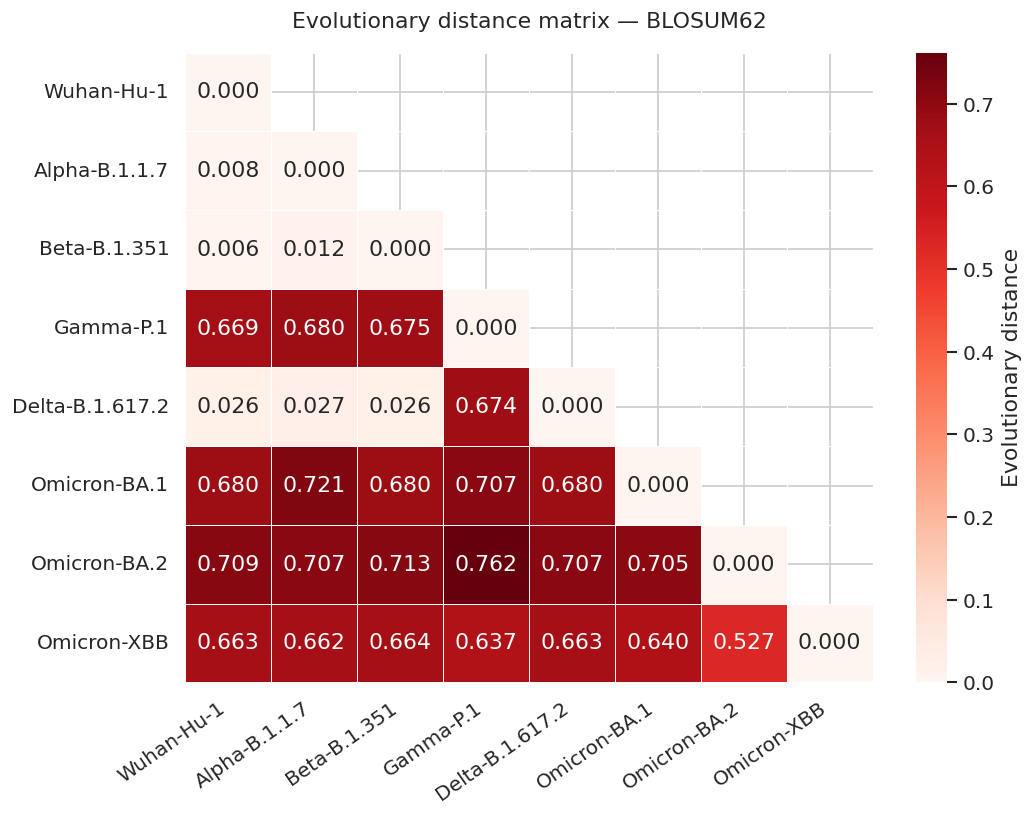

In [40]:
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(dist_df, dtype=bool), k=1)
sns.heatmap(
    dist_df,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Evolutionary distance'},
    ax=ax
)
ax.set_title('Evolutionary distance matrix — BLOSUM62', pad=15)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('spike_distance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 Albero filogenetico - UPGMA

**UPGMA** (*Unweighted Pair Group Method with Arithmetic Mean*) costruisce un albero filogenetico unendo iterativamente i gruppi di sequenze più simili.  

Questo metodo assume che tutte le linee evolutive evolvano alla stessa velocità, secondo l’ipotesi dell’**orologio molecolare** (*molecular clock*).  
Per questo motivo, UPGMA produce alberi ultrametrici, in cui tutte le foglie risultano equidistanti dalla radice.

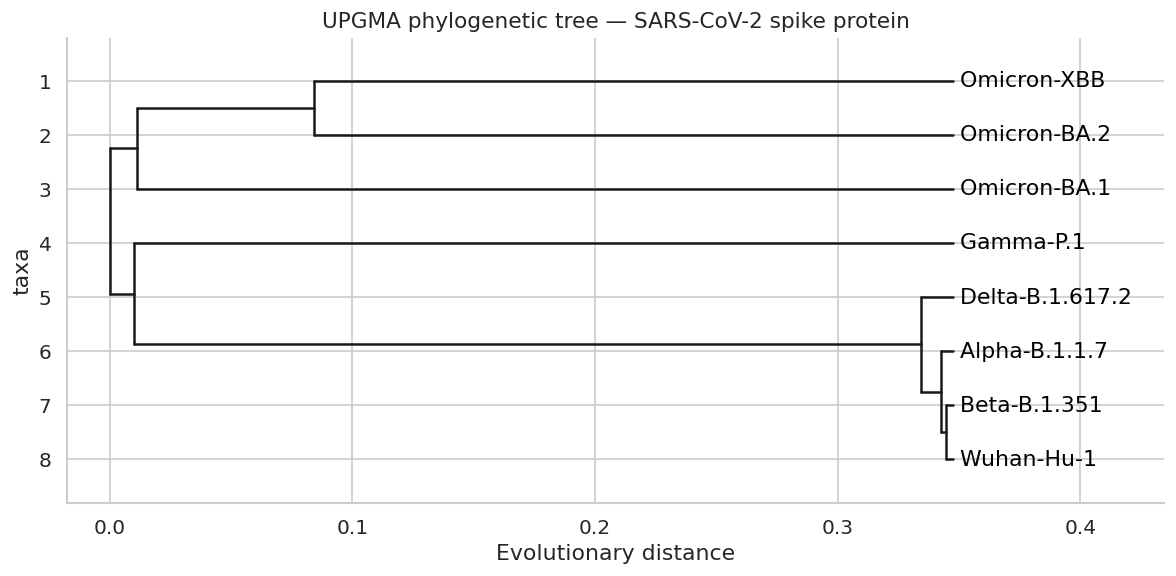

In [43]:
constructor=DistanceTreeConstructor(calculator)

tree_upgma=constructor.upgma(dist_matrix)

fig, ax = plt.subplots(figsize=(10, 5))
Phylo.draw(
    tree_upgma,
    axes=ax,
    do_show=False,
    label_func=lambda c: c.name if c.is_terminal() else '',
)
ax.set_title('UPGMA phylogenetic tree — SARS-CoV-2 spike protein', fontsize=13)
ax.set_xlabel('Evolutionary distance')

for line in ax.get_lines():
    line.set_color('#1D9E75')
    line.set_linewidth(1.8)
sns.despine()
plt.tight_layout()
plt.savefig('tree_upgma.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Phylogenetic tree — Neighbor-Joining


**Neighbor-Joining** corregge le differenze nei tassi evolutivi tra le diverse linee evolutive prima di unire le sequenze o i cluster.  

A differenza di UPGMA, non assume un tasso evolutivo costante ed è quindi più robusto quando le velocità di evoluzione variano tra i lineage, situazione molto comune nei dati biologici reali.

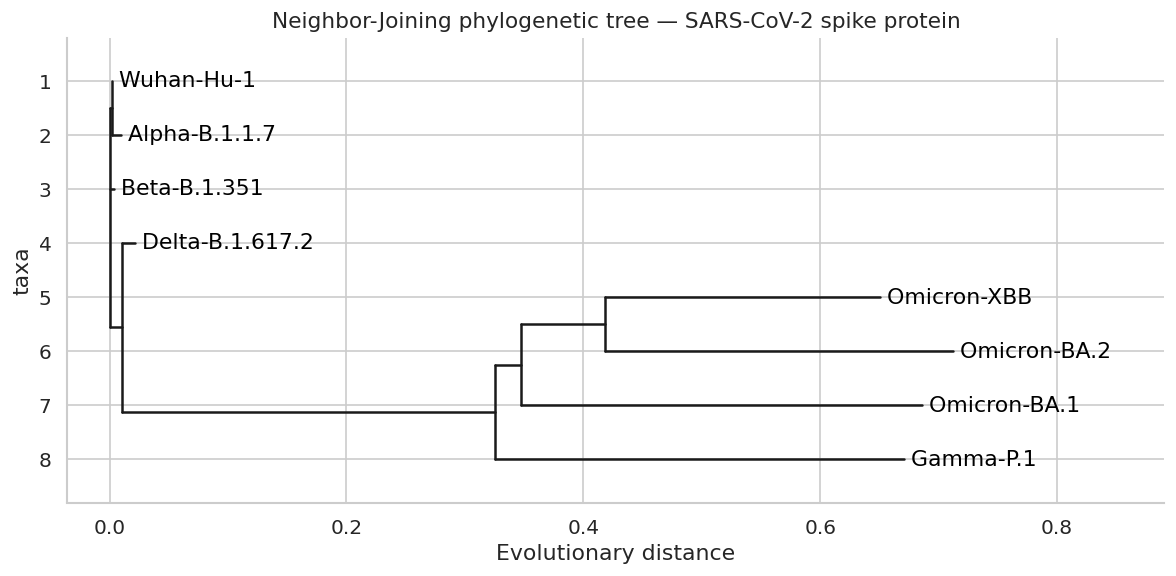

In [44]:
tree_nj = constructor.nj(dist_matrix)

fig, ax = plt.subplots(figsize=(10, 5))
Phylo.draw(
    tree_nj,
    axes=ax,
    do_show=False,
    label_func=lambda c: c.name if c.is_terminal() else '',
)
ax.set_title('Neighbor-Joining phylogenetic tree — SARS-CoV-2 spike protein', fontsize=13)
ax.set_xlabel('Evolutionary distance')
for line in ax.get_lines():
    line.set_color('#534AB7')
    line.set_linewidth(1.8)
sns.despine()
plt.tight_layout()
plt.savefig('tree_nj.png', dpi=150, bbox_inches='tight')
plt.show()

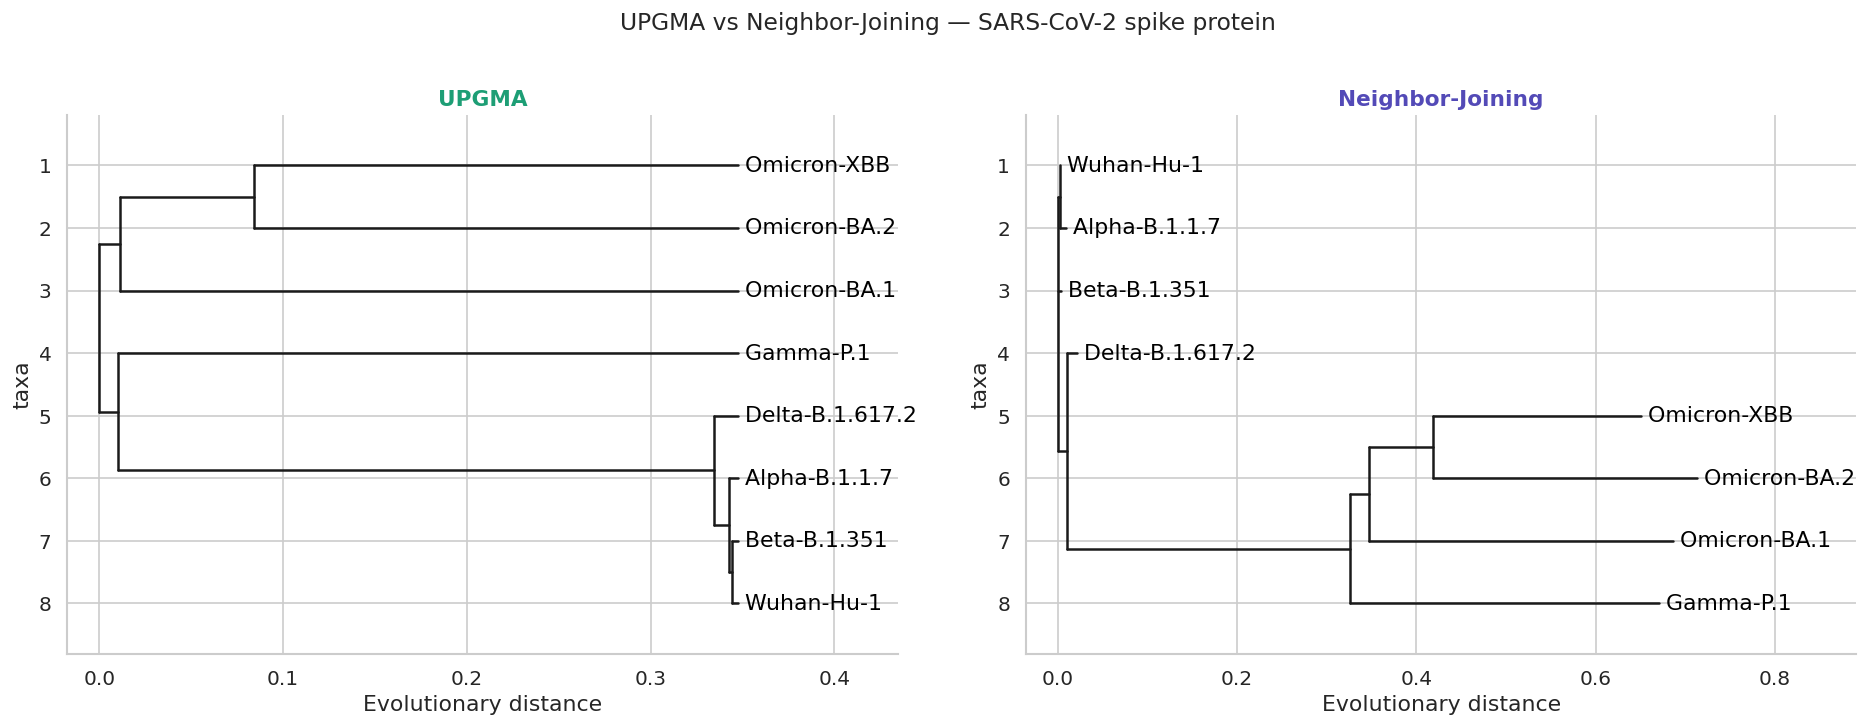

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tree, title, color in zip(
    axes,
    [tree_upgma, tree_nj],
    ['UPGMA', 'Neighbor-Joining'],
    ['#1D9E75', '#534AB7']
):
    Phylo.draw(tree, axes=ax, do_show=False,
               label_func=lambda c: c.name if c.is_terminal() else '')
    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Evolutionary distance')
    for line in ax.get_lines():
        line.set_color(color)
        line.set_linewidth(1.8)
    sns.despine(ax=ax)

fig.suptitle('UPGMA vs Neighbor-Joining — SARS-CoV-2 spike protein',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('tree_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
print('=== UPGMA ===')
Phylo.draw_ascii(tree_upgma)

print('\n=== Neighbor-Joining ===')
Phylo.draw_ascii(tree_nj)

=== UPGMA ===
                ______________________________________________ Omicron-XBB
    ___________|
  _|           |______________________________________________ Omicron-BA.2
 | |
_| |__________________________________________________________ Omicron-BA.1
 |
 | ___________________________________________________________ Gamma-P.1
 ||
  |                                                         _ Delta-B.1.617.2
  |________________________________________________________|
                                                           | , Alpha-B.1.1.7
                                                           |_|
                                                             , Beta-B.1.351
                                                             |
                                                             | Wuhan-Hu-1


=== Neighbor-Joining ===
 , Wuhan-Hu-1
 |
 | Alpha-B.1.1.7
 |
 | Beta-B.1.351
_|
 , Delta-B.1.617.2
 |
 |                                   ___________________ Omi

## Esportare gli alberi filogenetici

Il formato **Newick** è lo standard più utilizzato per rappresentare e salvare alberi filogenetici in formato testuale.  

I file `.nwk` possono essere aperti con software di visualizzazione filogenetica come **iTOL**, **FigTree** o **Dendroscope**, che permettono di esplorare e personalizzare gli alberi in modo più avanzato.

In [47]:
Phylo.write(tree_upgma, 'tree_upgma.nwk', 'newick')
Phylo.write(tree_nj,    'tree_nj.nwk',    'newick')


with open('tree_upgma.nwk') as f:
    print('UPGMA Newick:')
    print(f.read())

with open('tree_nj.nwk') as f:
    print('NJ Newick:')
    print(f.read())

UPGMA Newick:
(((Omicron-XBB:0.26348,Omicron-BA.2:0.26348)Inner4:0.07278,Omicron-BA.1:0.33626)Inner5:0.01144,(Gamma-P.1:0.33757,(Delta-B.1.617.2:0.01326,(Alpha-B.1.1.7:0.00503,(Beta-B.1.351:0.00320,Wuhan-Hu-1:0.00320)Inner1:0.00183)Inner2:0.00823)Inner3:0.32431)Inner6:0.01013)Inner7:0.00000;

NJ Newick:
((Wuhan-Hu-1:0.00055,Alpha-B.1.1.7:0.00735)Inner5:0.00192,Beta-B.1.351:0.00346,(Delta-B.1.617.2:0.01128,(((Omicron-XBB:0.23240,Omicron-BA.2:0.29455)Inner1:0.07040,Omicron-BA.1:0.33864)Inner2:0.02195,Gamma-P.1:0.34482)Inner3:0.31560)Inner4:0.01009)Inner6:0.00000;



### Summary finale

| Step | Tool | Output |
|------|------|--------|
| Download sequences | `Entrez.efetch()` | `spike_raw.fasta` |
| Multiple alignment | MAFFT via subprocess | `spike_aligned.fasta` |
| Conservation plot | NumPy + Matplotlib | `spike_conservation.png` |
| Identity heatmap | `pairwise_identity_matrix()` + seaborn | `spike_identity_heatmap.png` |
| Distance matrix | `DistanceCalculator('blosum62')` | `dist_df` |
| UPGMA tree | `DistanceTreeConstructor.upgma()` | `tree_upgma.nwk` |
| NJ tree | `DistanceTreeConstructor.nj()` | `tree_nj.nwk` |
| Tree visualization | `Bio.Phylo.draw()` | `tree_comparison.png` |


## Esercizi



### Esercizio 1: Cambia il modello di sostituzione

Per DistanceCalculator abbiamo usato la 'blosum62', ma esistono diversi modelli come 'identity' o 'pam250'.

Prova a ricostruire il NJ usando 'identity' o la 'pam250'.
Come cambia l'albero?

<details>
<summary>Show solution</summary>

```python
for model in ['identity', 'blosum62', 'pam250']:
    calc = DistanceCalculator(model)
    dm = calc.get_distance(alignment)
    tree = DistanceTreeConstructor(calc).nj(dm)
    print(f'\n=== NJ tree with model: {model} ===')
    Phylo.draw_ascii(tree)

```
</details>

---

### Esercizio 2 - Aggiungi una sequenza distante evolutivamente e vedi come cambia l'albero

Esempio. Aggiungi la proteina Spike di **SARS-CoV-1** (`AAP13441.1`) .

<details>
<summary>Show solution</summary>

```python
handle = Entrez.efetch(db='protein', id='AAP13441.1', rettype='fasta', retmode='text')
outgroup = SeqIO.read(handle, 'fasta')
outgroup.id = 'SARS-CoV-1'
outgroup.description = ''


all_seqs = list(SeqIO.parse(RAW_FASTA, 'fasta')) + [outgroup]
SeqIO.write(all_seqs, 'spike_with_outgroup.fasta', 'fasta')
run_mafft('spike_with_outgroup.fasta', 'spike_with_outgroup_aligned.fasta')

aln2 = AlignIO.read('spike_with_outgroup_aligned.fasta', 'fasta')
calc2 = DistanceCalculator('blosum62')
dm2 = calc2.get_distance(aln2)
tree_nj2 = DistanceTreeConstructor(calc2).nj(dm2)
Phylo.draw_ascii(tree_nj2)

```
</details>

---

### Esercizio 3 Altro gene, altra storia

Prova ripetere la stessa pipeline (Download-> MSA-> Conservazione -> NJ tree) usando un'altra proteina, come ad esempio **nucleocapsid protein** di Sars-CoV-2 invece della Spike.
Come cambia?

